# Exploring the model creation process
The functions within this file supersede the functions file until the functions file can be cleaned.

In [66]:
import os
import glob
import json
import pickle
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

import inc.functions as fn
from inc.indicators import apply_all_indicators


def save_model_assets(model, scaler, feature_columns, folder="inc/models", name="crypto_features"):
    """
    Save the model, scaler, and feature columns to the specified folder with a shared name prefix.
    """
    os.makedirs(folder, exist_ok=True)

    # Paths
    model_path = os.path.join(folder, f"{name}.keras")
    scaler_path = os.path.join(folder, f"{name}_scaler.pkl")
    features_path = os.path.join(folder, f"{name}_features.pkl")

    # Save model
    model.save(model_path)

    # Save scaler
    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)

    # Save feature columns
    with open(features_path, "wb") as f:
        pickle.dump(feature_columns, f)

    print(f"Model, scaler, and features saved to {folder} as {name}.*")

def load_model_assets(folder="inc/models", name="crypto_features"):
    """
    Load the model, scaler, and feature columns from the specified folder and shared name prefix.
    
    Returns:
        model: Keras model
        scaler: StandardScaler
        feature_columns: List[str]
    """
    # Paths
    model_path = os.path.join(folder, f"{name}.keras")
    scaler_path = os.path.join(folder, f"{name}_scaler.pkl")
    features_path = os.path.join(folder, f"{name}_features.pkl")

    # Load assets
    model = keras.models.load_model(model_path)

    with open(scaler_path, "rb") as f:
        scaler = pickle.load(f)

    with open(features_path, "rb") as f:
        feature_columns = pickle.load(f)

    print(f"Model, scaler, and features loaded from {folder} as {name}.*")
    return model, scaler, feature_columns

def create_profit_labels(df, profit_threshold=0.005, loss_threshold=-0.005, future_window=10):
    """
    Assigns BUY (1), SELL (-1), or HOLD (0) based on future high/low movement.
    
    Args:
        df: DataFrame with 'Close', 'High', and 'Low' prices.
        profit_threshold: Relative gain to label as BUY.
        loss_threshold: Relative drop to label as SELL.
        future_window: How many future rows to look ahead.
    Returns:
        Modified DataFrame with 'Label' column.
    """
    df = df.copy()
    df['Label'] = 0  # Default to HOLD

    closes = df['Close'].values
    highs = df['High'].rolling(window=future_window, min_periods=1).max().shift(-1)
    lows = df['Low'].rolling(window=future_window, min_periods=1).min().shift(-1)

    buy_trigger = ((highs - df['Close']) / df['Close']) > profit_threshold
    sell_trigger = ((lows - df['Close']) / df['Close']) < loss_threshold

    df.loc[buy_trigger, 'Label'] = 1
    df.loc[sell_trigger, 'Label'] = -1

    return df

def plot_signals(df, window_start=1000, window_end=1100):
    window = df.iloc[window_start:window_end]
    plt.figure(figsize=(14, 6))
    plt.plot(window['Close'].values, label='Close Price', color='gray')

    buys = window[window['Label'] == 1]
    sells = window[window['Label'] == -1]

    plt.scatter(buys.index, buys['Close'], color='green', label='BUY', marker='^', s=100)
    plt.scatter(sells.index, sells['Close'], color='red', label='SELL', marker='v', s=100)

    plt.legend()
    plt.title("Buy and Sell Signal Overlay")
    plt.xlabel("Index")
    plt.ylabel("Price")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def backtest_predictions(df, predictions, initial_balance=1000.0):
    """
    Simulates trading based on model predictions.
    Args:
        df: DataFrame with at least a 'Close' column
        predictions: array-like of model predictions (0=SELL, 1=HOLD, 2=BUY)
        initial_balance: Starting capital

    Returns:
        final_balance, trade_log (list of dicts)
    """
    balance = initial_balance
    position = None  # None or dict: {'entry_price': float, 'entry_index': int}
    trade_log = []

    for i in range(1, len(predictions)):
        price = df['Close'].iloc[i]
        action = predictions[i]

        # BUY signal and no position
        if action == 2 and position is None:
            position = {'entry_price': price, 'entry_index': i}

        # SELL signal and we have a position
        elif action == 0 and position is not None:
            entry_price = position['entry_price']
            profit = (price - entry_price) / entry_price
            balance *= (1 + profit)  # Compound gain/loss
            trade_log.append({
                'entry_index': position['entry_index'],
                'exit_index': i,
                'entry_price': entry_price,
                'exit_price': price,
                'return': profit
            })
            position = None  # Reset

        # HOLD: do nothing

    # Optional: close open position at end
    if position is not None:
        price = df['Close'].iloc[-1]
        profit = (price - position['entry_price']) / position['entry_price']
        balance *= (1 + profit)
        trade_log.append({
            'entry_index': position['entry_index'],
            'exit_index': len(df) - 1,
            'entry_price': position['entry_price'],
            'exit_price': price,
            'return': profit
        })

    return balance, trade_log

symbols = [
    "BTC-USD", "ETH-USD", "SOL-USD", "LTC-USD",
    "ADA-USD", "AVAX-USD", "DOGE-USD", "MATIC-USD",
    "XRP-USD", "PEPE-USD","XLM-USD"
]

### Focus on ADA-USD and visualize create_profit_labels to determine if on track visually

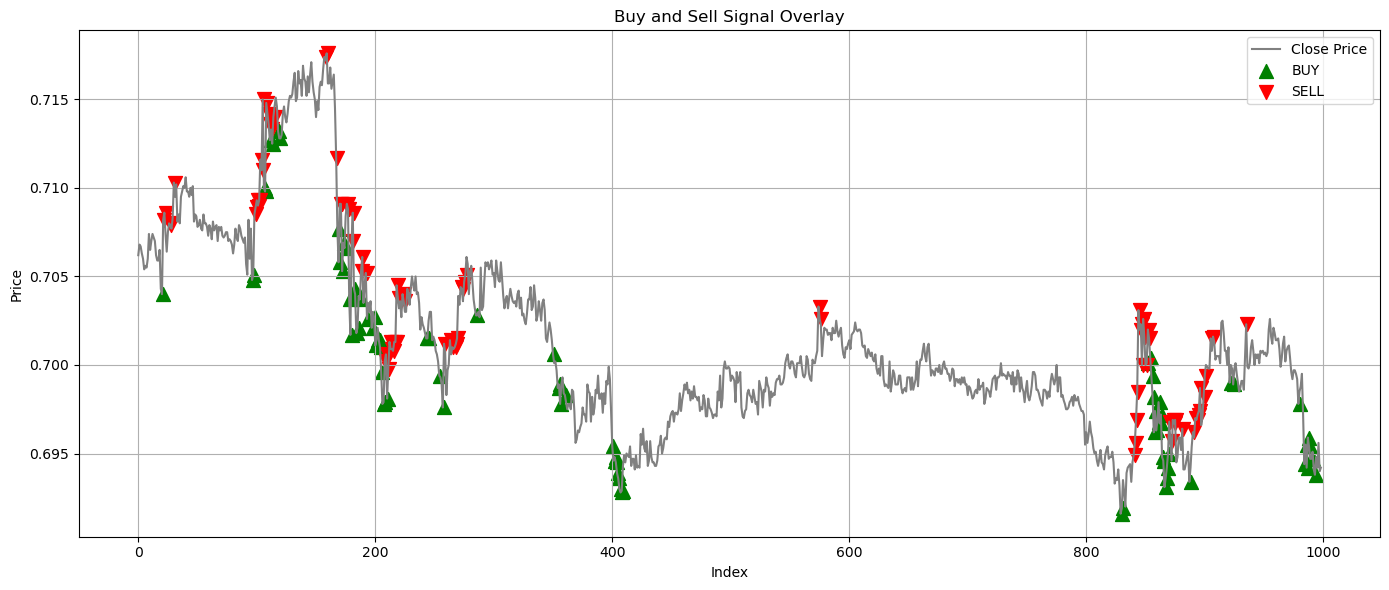

Label
 0    0.78731178
-1    0.11020420
 1    0.10248401
Name: proportion, dtype: float64


In [63]:
df = fn.load_crypto_data(symbols[4])
df = fn.apply_all_indicators(df)
df = create_profit_labels(df, profit_threshold=0.0048, loss_threshold=-0.005, future_window=9)
plot_signals(df, window_start=1, window_end=1000)
print(df['Label'].value_counts(normalize=True))

### Create the model
If everything looks balanced as best as can be, begin model. Focus on features more apt to make a difference and cause less noise.

In [90]:
df = fn.load_crypto_data(symbols[4])
df = fn.apply_all_indicators(df)
df = create_profit_labels(df, profit_threshold=0.0047, loss_threshold=-0.006, future_window=9)

features = ['MACD_Diff', 'Price_Position', 'Price_vs_Band', 'RSI', '%K',
            'MACD', '%D', 'Signal_Line', 'Fib_Bearish_200.0%', 'Fib_Bearish_261.8%',
            'Fib_Bearish_161.8%', 'Fib_Bearish_423.6%', 'Fib_Bearish_127.2%',
            'Trough', 'Fib_100.0%', 'Fib_61.8%', 'Fib_50.0%', 'Fib_38.2%', 'Spread']

X = df[features]
y = df['Label'].replace({-1: 0, 0: 1, 1: 2})

# Filter columns with >95% valid
X = X.dropna(axis=1, thresh=0.95 * len(X))
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
y = y.loc[X.index]  # Align

# Step 3: Train-test split & scale
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.25, random_state=78)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42)


# Step 4: Class weights
class_weights_array = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights_array))

# Step 5: Model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(96, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(48, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(24, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Step 6: Train
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
history = model.fit(X_train_final, y_train_final,
                    validation_data=(X_val, y_val),
                    epochs=50, batch_size=32, verbose=0,
                    class_weight=class_weights_dict,
                    callbacks=[early_stop])


# Step 7: Evaluate
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"✅ Accuracy: {test_accuracy:.4f} | Loss: {test_loss:.4f}")

c:\Users\James\anaconda3\envs\gideon\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


✅ Accuracy: 0.8461 | Loss: 0.4433


### Save the model

In [ ]:
save_model_assets(model, scaler, X.columns.tolist(), folder="inc/models", name=symbols[4])

Model, scaler, and features saved to inc/models as ADA-USD.*


### Check confidence distribution to ensure it's not spiked at 1 and display confusion matrix

796/796 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step


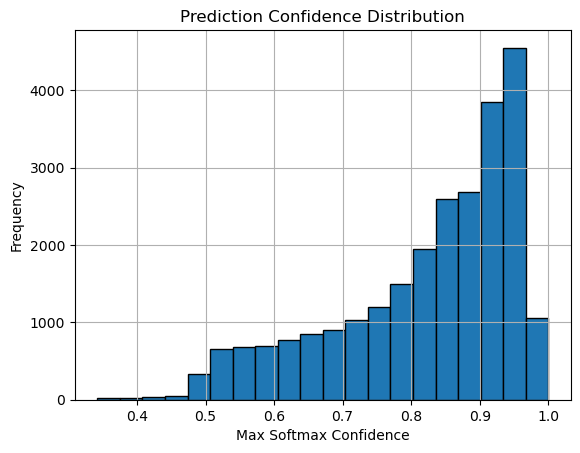

796/796 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step


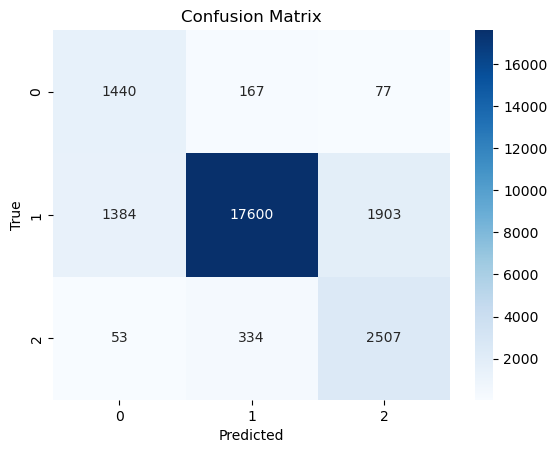

In [104]:
import matplotlib.pyplot as plt

probs = model.predict(X_test_scaled)
confidences = probs.max(axis=1)

plt.hist(confidences, bins=20, edgecolor='k')
plt.title("Prediction Confidence Distribution")
plt.xlabel("Max Softmax Confidence")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

y_pred = model.predict(X_test_scaled).argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


### Try backtesting the prediction from historic data

In [106]:
df_test = fn.load_crypto_data("ADA-USD")
# Ensure alignment
df_test = df_test.iloc[-len(X_test_scaled):]

# Generate predictions with confidence thresholds
probs = model.predict(X_test_scaled)
predictions = []

buy_thresh = 0.70
sell_thresh = 0.75

for prob in probs:
    pred_class = np.argmax(prob)
    confidence = np.max(prob)
    if pred_class == 2 and confidence >= buy_thresh:
        predictions.append(2)
    elif pred_class == 0 and confidence >= sell_thresh:
        predictions.append(0)
    else:
        predictions.append(1)

# Backtest using upgraded predictions
final_balance, trades = backtest_predictions(df_test, predictions, initial_balance=1000.0)

# Summary
print(f"Final Balance: ${final_balance:.2f}")
print(f"Total Trades: {len(trades)}")
print(f"Win Rate: {sum(t['return'] > 0 for t in trades) / len(trades):.2%}")



796/796 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step
Final Balance: $1017.15
Total Trades: 1140
Win Rate: 49.04%


## Fine tune buy and sell confidence thresholds

In [107]:
import numpy as np

# Setup ranges
buy_range = np.arange(0.65, 0.8, 0.01)
sell_range = np.arange(0.60, 0.75, 0.01)

# Run prediction once
probs = model.predict(X_test_scaled)
df_test = df.iloc[-len(X_test_scaled):]

results = []

# Sweep through thresholds
for b_thresh in buy_range:
    for s_thresh in sell_range:
        predictions = []

        for prob in probs:
            pred_class = np.argmax(prob)
            confidence = np.max(prob)

            if pred_class == 2 and confidence >= b_thresh:
                predictions.append(2)
            elif pred_class == 0 and confidence >= s_thresh:
                predictions.append(0)
            else:
                predictions.append(1)

        final_balance, trades = backtest_predictions(df_test, predictions, initial_balance=1000.0)
        win_rate = sum(t['return'] > 0 for t in trades) / len(trades) if trades else 0.0

        results.append({
            'Buy_Threshold': round(b_thresh, 2),
            'Sell_Threshold': round(s_thresh, 2),
            'Final_Balance': final_balance,
            'Total_Trades': len(trades),
            'Win_Rate': round(win_rate, 4)
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by=['Final_Balance', 'Win_Rate'], ascending=False, inplace=True)
results_df

796/796 ━━━━━━━━━━━━━━━━━━━━ 1s 653us/step


,Buy_Threshold,Sell_Threshold,Final_Balance,Total_Trades,Win_Rate
95,0.70,0.75,1124.85939275,1140,0.4500
63,0.68,0.75,1124.23413539,1161,0.4505
111,0.71,0.75,1123.90812826,1135,0.4502
47,0.67,0.75,1123.64175264,1168,0.4503
94,0.70,0.74,1122.20036402,1153,0.4501
...,...,...,...,...,...
242,0.80,0.62,991.76931509,1165,0.4498
225,0.79,0.61,982.93427556,1194,0.4497
241,0.80,0.61,981.79844205,1178,0.4491
224,0.79,0.60,980.15057063,1204,0.4477
